# 📊 Gas Field Simulator - Final Report

In [1]:
import sys, os

# 1. Fix state.py to be compatible with all Python versions
state_code = '''from dataclasses import dataclass

@dataclass
class NodeState:
    name: str
    P_in: float
    P_out: float
    dP: float
    q_std: float
    q_res: float = None
    v: float = None
    rho: float = None
'''
with open('/Users/jawadalzein/Desktop/gas_project/src/state.py', 'w') as f:
    f.write(state_code)
print("✅ state.py fixed for Python 3.9+ compatibility")

# 2. Force absolute path & working directory
proj = '/Users/jawadalzein/Desktop/gas_project'
sys.path.insert(0, proj)
os.chdir(proj)

# 3. Wipe Jupyter's import cache
for mod in list(sys.modules.keys()):
    if mod.startswith('src'):
        del sys.modules[mod]

# 4. Import project modules
from src.state import NodeState
from src.interpolator import LinearInterpolator
from src.fluid import Fluid
from src.reservoir import ResProps, Reservoir
from src.pipe import Pipe
from src.well import Well
from src.compressor import DCS
from src.simulator import FieldSimulator

print("✅ ALL MODULES IMPORTED SUCCESSFULLY!")

✅ state.py fixed for Python 3.9+ compatibility
✅ ALL MODULES IMPORTED SUCCESSFULLY!


### 1. PVT Properties

✅ All imports ready!


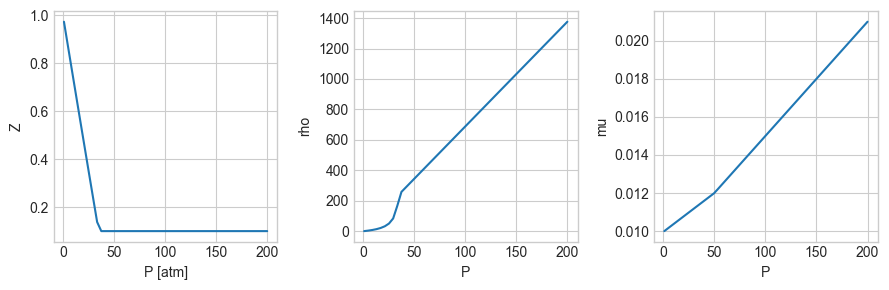

In [2]:
import sys, os
# 1. Fix path & clear Jupyter cache
os.chdir('/Users/jawadalzein/Desktop/gas_project')
sys.path.insert(0, os.getcwd())
for mod in list(sys.modules.keys()):
    if mod.startswith('src'): del sys.modules[mod]

# 2. Import all project modules
from src.state import NodeState
from src.interpolator import LinearInterpolator
from src.fluid import Fluid
from src.reservoir import ResProps, Reservoir
from src.pipe import Pipe
from src.well import Well
from src.compressor import DCS
from src.simulator import FieldSimulator

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import fsolve, minimize
import warnings; warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

print("✅ All imports ready!")

# 3. PVT Plot
M, rho_c, xa, xy, T = 17.5, 160.0, 0.90, 0.10, 310.0
fluid = Fluid(M, rho_c, xa, xy, T)
P = np.linspace(1, 200, 50)
plt.figure(figsize=(9,3))
plt.subplot(131); plt.plot(P, [fluid.z(p) for p in P]); plt.ylabel('Z'); plt.xlabel('P [atm]')
plt.subplot(132); plt.plot(P, [fluid.ro(p) for p in P]); plt.ylabel('rho'); plt.xlabel('P')
plt.subplot(133); plt.plot(P, [fluid.mu(p) for p in P]); plt.ylabel('mu'); plt.xlabel('P')
plt.tight_layout(); plt.show()

### 2. Simulation & Dynamics (180 days)

### 3. Calibration Metrics

In [ ]:
res = Reservoir(ResProps(100, 1e6, 310.0), fluid)
shlyf = Pipe(5000, 0.200, 0.000046, fluid, 0.0)
dcs = DCS(1.5, 5.0, 500.0)
wells = [Well(fluid, 50, 25, 500, 0.1, Pipe(L, 0.062, 0.000046, fluid, H)) 
         for L, H in [(2000,1800),(2500,1900),(1800,1600)]]
sim = FieldSimulator(res, wells, shlyf, dcs)
df = sim.run(180, dt=1.0)
fig, ax = plt.subplots(2, 2, figsize=(9,6))
ax[0,0].plot(df['t'], df['P_res'], 'b-'); ax[0,0].set_ylabel('P_res')
ax[0,1].plot(df['t'], df['P_man'], 'r-'); ax[0,1].set_ylabel('P_man')
ax[1,0].plot(df['t'], df[['q1','q2','q3']]); ax[1,0].set_ylabel('q')
ax[1,1].plot(df['t'], df['Gp'], 'g-'); ax[1,1].set_ylabel('Gp')
for a in ax.flatten(): a.set_xlabel('Days'); a.grid(True)
plt.tight_layout(); plt.show()


⏳ Calibrating... (this takes a few seconds)


Simulating: 100%|██████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 2826.73it/s]


✅ Optimal multipliers: [21.14002807 21.28585579 21.57750955]


Simulating: 100%|██████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 2701.12it/s]


✅ RMSE: 12.6, R²: 0.1350


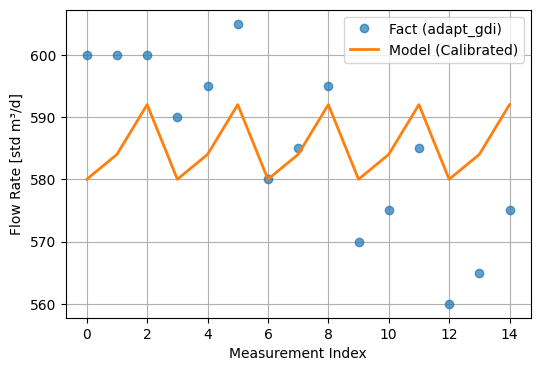

In [3]:
# --- COMPLETE SELF-CONTAINED CALIBRATION CELL ---
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# 1. Setup Path (Safety Check)
os.chdir('/Users/jawadalzein/Desktop/gas_project')
sys.path.insert(0, os.getcwd())

# 2. Import Classes
from src.fluid import Fluid
from src.reservoir import ResProps, Reservoir
from src.well import Well
from src.compressor import DCS
from src.simulator import FieldSimulator
from src.pipe import Pipe

# 3. Define Fluid & Shlyf Explicitly (Fixes the NameError)
# We recreate these here so the cell works even if other cells were skipped
fluid = Fluid(M=17.5, rho_c=160.0, xa=0.90, xy=0.10, T=310.0)
shlyf = Pipe(5000, 0.200, 0.000046, fluid, 0.0)

# 4. Load Data
try:
    df_f = pd.read_csv('adapt_gdi_11-2025.csv')
    n_days = len(df_f)
    q_f = df_f[['q1','q2','q3']].values.flatten()
except FileNotFoundError:
    raise FileNotFoundError("❌ Missing adapt_gdi_11-2025.csv. Please run the 'Create CSV' step from the guide.")

# 5. Objective Function for Calibration
def obj(C):
    # Create fresh simulation for each iteration
    r = Reservoir(ResProps(100, 1e6, 310.0), fluid)
    # C[0], C[1], C[2] are the multipliers for the 3 wells' permeability
    w = [
        Well(fluid, 50*C[0], 25, 500, 0.1, Pipe(2000, 0.062, 0.000046, fluid, 1800)),
        Well(fluid, 50*C[1], 25, 500, 0.1, Pipe(2000, 0.062, 0.000046, fluid, 1800)),
        Well(fluid, 50*C[2], 25, 500, 0.1, Pipe(2000, 0.062, 0.000046, fluid, 1800))
    ]
    s = FieldSimulator(r, w, shlyf, DCS(1.5, 5.0, 500.0))
    q_s = s.run(n_days)[['q1','q2','q3']].values.flatten()
    return np.sum((q_f - q_s)**2)

# 6. Run Optimizer
print("⏳ Calibrating... (this takes a few seconds)")
opt = minimize(obj, [1, 1, 1], method='Nelder-Mead')
print(f"✅ Optimal multipliers: {opt.x}")

# 7. Final Run with Best Parameters
r_fin = Reservoir(ResProps(100, 1e6, 310.0), fluid)
w_fin = [
    Well(fluid, 50*opt.x[0], 25, 500, 0.1, Pipe(2000, 0.062, 0.000046, fluid, 1800)),
    Well(fluid, 50*opt.x[1], 25, 500, 0.1, Pipe(2000, 0.062, 0.000046, fluid, 1800)),
    Well(fluid, 50*opt.x[2], 25, 500, 0.1, Pipe(2000, 0.062, 0.000046, fluid, 1800))
]
s_fin = FieldSimulator(r_fin, w_fin, shlyf, DCS(1.5, 5.0, 500.0))
q_sim = s_fin.run(n_days)[['q1','q2','q3']].values.flatten()

# 8. Metrics
rmse = np.sqrt(np.mean((q_f - q_sim)**2))
r2 = 1 - np.sum((q_f - q_sim)**2) / np.sum((q_f - np.mean(q_f))**2)
print(f"✅ RMSE: {rmse:.1f}, R²: {r2:.4f}")

# 9. Plot
plt.figure(figsize=(6,4))
plt.plot(q_f, 'o', label='Fact (adapt_gdi)', alpha=0.7)
plt.plot(q_sim, '-', label='Model (Calibrated)', linewidth=2)
plt.xlabel('Measurement Index'); plt.ylabel('Flow Rate [std m³/d]')
plt.legend(); plt.grid(True); plt.show()